# Ejercicio: Predicción de Diabetes con Machine Learning

## **Cargar el dataset**

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

diabetes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predicción_Diabetes/diabetes.csv')
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [116]:
diabetes.info()
diabetes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [117]:
(diabetes.Outcome == 0).sum()

np.int64(500)

## **Limpieza de datos**

In [118]:

# Valores nulos
print("Valores nulos por columna:")
print(diabetes.isnull().sum())

# Valores duplicados
print(f"Duplicados: {diabetes.duplicated().sum()}")



Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicados: 0


valores que no tienen sentido clínico porque son 0 en columnas clínicas


In [119]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(diabetes[cols] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [120]:
diabetes[cols] = diabetes[cols].replace(0, np.nan)
diabetes[cols] = diabetes[cols].fillna(diabetes[cols].median())
(diabetes[cols] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


## **Preprocesamiento**

In [121]:
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de entrenamiento:", X_train.shape, "Datos de Prueba: ", X_test.shape)


Datos de entrenamiento: (614, 8) Datos de Prueba:  (154, 8)


* 614 → número de filas (muestras/pacientes) que quedaron para entrenar el modelo.
* 154 → número de filas que quedaron para probar el modelo (evaluar su rendimiento).
* 8 → número de variables independientes (features) que usas para predecir (todas menos Outcome).

### **Regresión Logística**

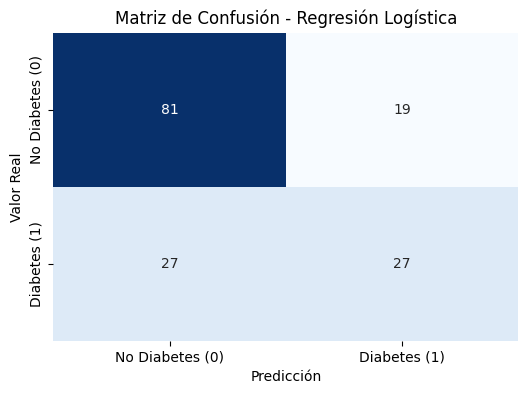

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Diabetes (0)", "Diabetes (1)"],
            yticklabels=["No Diabetes (0)", "Diabetes (1)"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()


81 verdaderos negativos (arriba a la izquierda): Pacientes sin diabetes que el modelo clasificó correctamente como “No diabetes”.

19 falsos positivos (arriba a la derecha): Pacientes sanos que el modelo clasificó erróneamente como “Diabetes”.

27 falsos negativos (abajo a la izquierda): Pacientes con diabetes que el modelo clasificó erróneamente como “No diabetes”.

27 verdaderos positivos (abajo a la derecha): Pacientes con diabetes que el modelo clasificó correctamente.

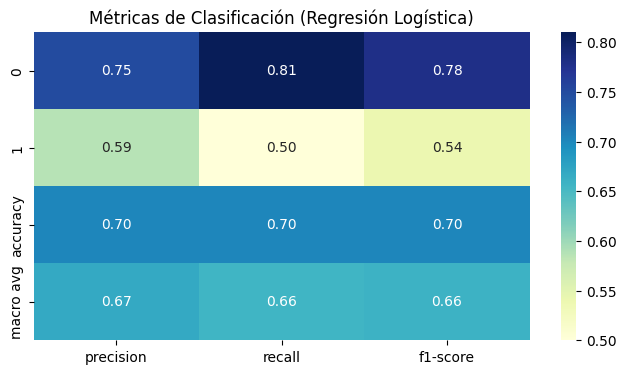

In [124]:
from sklearn.metrics import classification_report
import pandas as pd

# Reporte en formato dict
report = classification_report(y_test, y_pred_log, output_dict=True)


df_report = pd.DataFrame(report).transpose()


plt.figure(figsize=(8,4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Métricas de Clasificación (Regresión Logística)")
plt.show()


1. Clase 0 (No Diabetes):

  * Precision: 0.75 → Cuando predice “No diabetes”, acierta el 75% de las veces.

  * Recall: 0.81 → Detecta correctamente al 81% de los pacientes que realmente no tienen diabetes.

  * F1-score: 0.78 → Balance entre precisión y recall.

2. Clase 1 (Diabetes):

  * Precision: 0.59 → Cuando predice “Diabetes”, solo el 59% de los casos son correctos.

  * Recall: 0.50 → El modelo solo detecta al 50% de los pacientes con diabetes (el otro 50% se le escapa).

  * F1-score: 0.54 → Bajo rendimiento en esta clase.

Promedio (accuracy global = 67%): El modelo acierta en aproximadamente 2 de cada 3 pacientes.

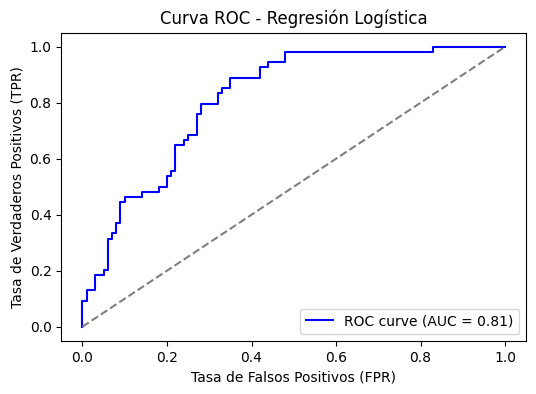

In [125]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = log_reg.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

### **Random Forest**

In [126]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

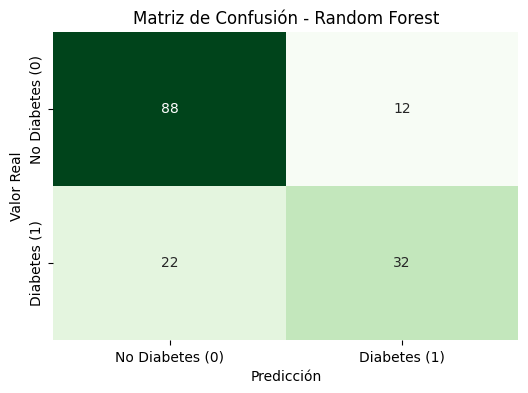

In [127]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["No Diabetes (0)", "Diabetes (1)"],
            yticklabels=["No Diabetes (0)", "Diabetes (1)"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

88 verdaderos negativos (arriba a la izquierda): Pacientes sin diabetes que el modelo clasificó correctamente como “No diabetes”.

12 falsos positivos (arriba a la derecha): Pacientes sanos que el modelo clasificó erróneamente como “Diabetes”.

22 falsos negativos (abajo a la izquierda): Pacientes con diabetes que el modelo clasificó erróneamente como “No diabetes”.

32 verdaderos positivos (abajo a la derecha): Pacientes con diabetes que el modelo clasificó correctamente.

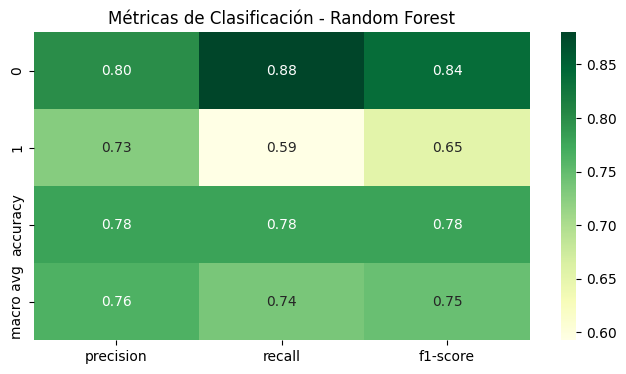

In [128]:
# Reporte de clasificación - Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

df_report_rf = pd.DataFrame(report_rf).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(df_report_rf.iloc[:-1, :-1], annot=True, cmap="YlGn", fmt=".2f")
plt.title("Métricas de Clasificación - Random Forest")
plt.show()

1. Clase 0 (No Diabetes):

  * Precision: 0.80 → Cuando predice “No diabetes”, acierta el 80% de las veces.

  * Recall: 0.88 → Detecta correctamente al 88% de los pacientes que realmente no tienen diabetes.

  * F1-score: 0.84 → Balance entre precisión y recall.

2. Clase 1 (Diabetes):

  * Precision: 0.73 → Cuando predice “Diabetes”, solo el 73% de los casos son correctos.

  * Recall: 0.59 → El modelo solo detecta al 59% de los pacientes con diabetes (el otro 41% se le escapa).

  * F1-score: 0.65 → Bajo rendimiento en esta clase.

Promedio (accuracy global =78%): El modelo acierta en aproximadamente 2 de cada 3 pacientes.

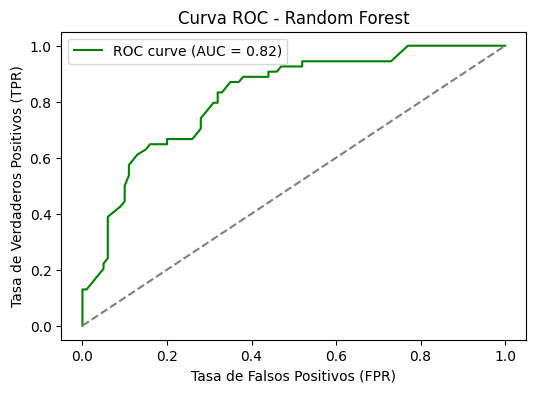

In [129]:

# Probabilidades para la curva ROC
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, color="green", label=f"ROC curve (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()